# Filter Benchmark + EfficientNetV2-L (Geometry-Aware)

This notebook is based on the filter benchmark pipeline, but uses the main choices that usually improve performance in the EfficientNet notebook:
- input resolution 512x512
- EfficientNetV2-L pretrained on ImageNet
- Focal Loss for class imbalance
- stronger augmentation
- geometry-aware preprocessing (pad-to-square before resize for rectangular images, including type V).

In [1]:
import os
import json
import copy
import random
import warnings
from typing import Callable

import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import torchvision.transforms as T
from torchvision.models import efficientnet_v2_l

from monai.losses import FocalLoss
from monai.utils import set_determinism

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    auc,
    classification_report,
    confusion_matrix,
)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings('ignore')

DATA_ROOT = '/mounts/mecd-ap-g5/data'
RESULTS_ROOT = '/mounts/mecd-ap-g5/results'
MODELS_ROOT = '/mounts/mecd-ap-g5/models'
NOTEBOOK_NAME = 'filter_benchmark_efficientnet_v2_l'
RESULTS_DIR = os.path.join(RESULTS_ROOT, NOTEBOOK_NAME)
MODELS_DIR = os.path.join(MODELS_ROOT, NOTEBOOK_NAME)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

SEED = 42
IMG_SIZE = 512
BATCH_SIZE = 4
NUM_WORKERS = 4
NUM_EPOCHS = 40
PATIENCE = 10
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
USE_PRETRAINED = True
GEOMETRY_MODE = 'pad_resize_if_rect'  # options: direct_resize, pad_resize_if_rect
USE_CLAHE = False

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

set_determinism(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('VRAM (GB):', torch.cuda.get_device_properties(0).total_memory / 1e9)
print('RESULTS_DIR:', RESULTS_DIR)
print('MODELS_DIR:', MODELS_DIR)

Device: cpu
RESULTS_DIR: /mounts/mecd-ap-g5/results/filter_benchmark_efficientnet_v2_l
MODELS_DIR: /mounts/mecd-ap-g5/models/filter_benchmark_efficientnet_v2_l


In [2]:
METADATA_PATH = os.path.join(DATA_ROOT, 'MIQR-CC-Dataset', 'metadata.csv')
df = pd.read_csv(METADATA_PATH)

EXCLUDED_LABELS = {'unlabeled', 'unlabelled', 'unlabbeled'}
FUSED_LABEL_MAP = {
    'Benign Stricture': 'Stricture',
    'Malignant Stricture': 'Stricture',
    'Biliary Leaks': 'Biliary Leaks',
    'Lithiasis': 'Lithiasis',
    'Normal': 'Normal',
}
FINAL_CLASSES = ['Biliary Leaks', 'Lithiasis', 'Normal', 'Stricture']

filtered = df[(df['Keep'].astype(str).str.strip().str.lower() == 'keep') & (~df['Label'].astype(str).str.strip().str.lower().isin(EXCLUDED_LABELS))].copy()
filtered['Label'] = filtered['Label'].astype(str).str.strip()
filtered['final_label'] = filtered['Label'].map(FUSED_LABEL_MAP)
filtered = filtered[filtered['final_label'].isin(FINAL_CLASSES)].copy()
filtered['image_path'] = filtered['processed_image_path'].apply(lambda p: os.path.join(DATA_ROOT, 'MIQR-CC-Dataset', p))
filtered = filtered[filtered['image_path'].apply(os.path.exists)].copy().reset_index(drop=True)

class_names = list(FINAL_CLASSES)
class_to_idx = {label_name: idx for idx, label_name in enumerate(class_names)}
filtered['target'] = filtered['final_label'].map(class_to_idx)

print('Total filtered samples:', len(filtered))
print('Class distribution:')
print(filtered['final_label'].value_counts())
print('Image type distribution:')
print(filtered['image_type'].value_counts())

Total filtered samples: 1568
Class distribution:
final_label
Lithiasis        726
Stricture        392
Normal           299
Biliary Leaks    151
Name: count, dtype: int64
Image type distribution:
image_type
S    1521
V      47
Name: count, dtype: int64


In [3]:
patient_summary = filtered.groupby('patient_id').agg(patient_label=('final_label', lambda x: x.mode().iloc[0])).reset_index()
train_patients, temp_patients = train_test_split(
    patient_summary,
    test_size=0.30,
    random_state=SEED,
    stratify=patient_summary['patient_label']
)
val_patients, test_patients = train_test_split(
    temp_patients,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_patients['patient_label']
)

train_df = filtered[filtered['patient_id'].isin(train_patients['patient_id'])].copy().reset_index(drop=True)
val_df = filtered[filtered['patient_id'].isin(val_patients['patient_id'])].copy().reset_index(drop=True)
test_df = filtered[filtered['patient_id'].isin(test_patients['patient_id'])].copy().reset_index(drop=True)

print('Split sizes:')
print('train:', len(train_df), 'val:', len(val_df), 'test:', len(test_df))

for split_name, split_df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    print(f'\n{split_name} label distribution:')
    print(split_df['final_label'].value_counts())
    print(f'{split_name} image_type distribution:')
    print(split_df['image_type'].value_counts())

Split sizes:
train: 1001 val: 313 test: 254

train label distribution:
final_label
Lithiasis        468
Stricture        249
Normal           206
Biliary Leaks     78
Name: count, dtype: int64
train image_type distribution:
image_type
S    967
V     34
Name: count, dtype: int64

val label distribution:
final_label
Lithiasis        142
Stricture         58
Normal            58
Biliary Leaks     55
Name: count, dtype: int64
val image_type distribution:
image_type
S    304
V      9
Name: count, dtype: int64

test label distribution:
final_label
Lithiasis        116
Stricture         85
Normal            35
Biliary Leaks     18
Name: count, dtype: int64
test image_type distribution:
image_type
S    250
V      4
Name: count, dtype: int64


In [4]:
def pad_to_square(image: Image.Image, fill=(0, 0, 0)) -> Image.Image:
    w, h = image.size
    if w == h:
        return image
    side = max(w, h)
    canvas = Image.new(image.mode, (side, side), fill)
    canvas.paste(image, ((side - w) // 2, (side - h) // 2))
    return canvas

def apply_clahe_rgb(image: Image.Image, clip_limit=2.0, tile_grid_size=(8, 8)) -> Image.Image:
    rgb = np.array(image.convert('RGB'))
    lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB)
    l_channel, a_channel, b_channel = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    l_channel = clahe.apply(l_channel)
    merged = cv2.merge((l_channel, a_channel, b_channel))
    out = cv2.cvtColor(merged, cv2.COLOR_LAB2RGB)
    return Image.fromarray(out)

def preprocess_image(image: Image.Image, geometry_mode='pad_resize_if_rect', use_clahe=False) -> Image.Image:
    image = image.convert('RGB')
    if use_clahe:
        image = apply_clahe_rgb(image)
    if geometry_mode == 'pad_resize_if_rect':
        image = pad_to_square(image)
    elif geometry_mode == 'direct_resize':
        pass
    else:
        raise ValueError(f'Unknown geometry_mode: {geometry_mode}')
    image = image.resize((IMG_SIZE, IMG_SIZE))
    return image

In [5]:
class ERCPDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, transform: Callable, geometry_mode='pad_resize_if_rect', use_clahe=False):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.geometry_mode = geometry_mode
        self.use_clahe = use_clahe

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]
        image = Image.open(row['image_path']).convert('RGB')
        image = preprocess_image(image, geometry_mode=self.geometry_mode, use_clahe=self.use_clahe)
        image = self.transform(image)
        target = int(row['target'])
        return image, target

train_transform = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=15),
    T.ColorJitter(brightness=0.15, contrast=0.15),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

train_ds = ERCPDataset(train_df, train_transform, geometry_mode=GEOMETRY_MODE, use_clahe=USE_CLAHE)
val_ds = ERCPDataset(val_df, eval_transform, geometry_mode=GEOMETRY_MODE, use_clahe=USE_CLAHE)
test_ds = ERCPDataset(test_df, eval_transform, geometry_mode=GEOMETRY_MODE, use_clahe=USE_CLAHE)

class_counts = train_df['target'].value_counts().sort_index()
class_weights = torch.tensor(len(train_df) / (len(class_counts) * class_counts.values), dtype=torch.float32, device=device)
weight_lookup = {i: float(w) for i, w in enumerate(class_weights.detach().cpu().numpy())}
sample_weights = train_df['target'].map(weight_lookup).astype(float).tolist()
train_sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=train_sampler, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

print('Class weights:', class_weights)

Class weights: tensor([3.2083, 0.5347, 1.2148, 1.0050])


In [6]:
def build_efficientnet_v2_l(num_classes, pretrained=True):
    try:
        from torchvision.models import EfficientNet_V2_L_Weights
        weights = EfficientNet_V2_L_Weights.DEFAULT if pretrained else None
        model = efficientnet_v2_l(weights=weights)
    except Exception:
        model = efficientnet_v2_l(pretrained=pretrained)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    return model


def compute_metrics(y_true, y_pred, y_prob, class_names):
    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'macro_precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'macro_recall': recall_score(y_true, y_pred, average='macro', zero_division=0),
    }
    y_true_bin = label_binarize(y_true, classes=list(range(len(class_names))))
    try:
        metrics['roc_auc_ovo_macro'] = roc_auc_score(y_true_bin, y_prob, average='macro', multi_class='ovo')
    except Exception:
        metrics['roc_auc_ovo_macro'] = np.nan
    try:
        metrics['pr_auc_macro'] = average_precision_score(y_true_bin, y_prob, average='macro')
    except Exception:
        metrics['pr_auc_macro'] = np.nan
    return metrics

In [7]:
def evaluate(model, loader, criterion):
    model.eval()
    all_targets, all_preds, all_probs = [], [], []
    running_loss = 0.0
    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device)
            targets = targets.to(device)
            outputs = model(images)
            loss = criterion(outputs, targets)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)
            running_loss += loss.item() * images.size(0)
            all_targets.extend(targets.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    avg_loss = running_loss / len(loader.dataset)
    all_probs = np.array(all_probs)
    metrics = compute_metrics(all_targets, all_preds, all_probs, class_names)
    metrics['loss'] = avg_loss
    return metrics, np.array(all_targets), np.array(all_preds), all_probs


def train_model():
    model = build_efficientnet_v2_l(len(class_names), pretrained=USE_PRETRAINED).to(device)
    criterion = FocalLoss(to_onehot_y=True)
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
    scaler = torch.amp.GradScaler('cuda', enabled=torch.cuda.is_available())

    best_state = copy.deepcopy(model.state_dict())
    best_val_f1 = -1.0
    best_epoch = 0
    epochs_without_improvement = 0
    history = []

    for epoch in range(NUM_EPOCHS):
        model.train()
        running_loss = 0.0
        all_targets, all_preds = [], []

        for images, targets in train_loader:
            images = images.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast(device_type=device.type, enabled=torch.cuda.is_available()):
                outputs = model(images)
                loss = criterion(outputs, targets)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)
            running_loss += loss.item() * images.size(0)
            all_targets.extend(targets.detach().cpu().numpy())
            all_preds.extend(preds.detach().cpu().numpy())

        train_loss = running_loss / len(train_loader.dataset)
        train_f1 = f1_score(all_targets, all_preds, average='macro', zero_division=0)

        val_metrics, _, _, _ = evaluate(model, val_loader, criterion)
        val_f1 = val_metrics['macro_f1']

        history.append({
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'train_macro_f1': train_f1,
            'val_loss': val_metrics['loss'],
            'val_macro_f1': val_f1,
            'val_accuracy': val_metrics['accuracy'],
            'val_auc': val_metrics['roc_auc_ovo_macro'],
        })

        scheduler.step()

        print(f"Epoch {epoch + 1:02d} | train_loss {train_loss:.4f} | train_f1 {train_f1:.4f} | val_f1 {val_f1:.4f}")

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_epoch = epoch + 1
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, os.path.join(MODELS_DIR, 'best_efficientnet_v2_l_geometry.pth'))
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= PATIENCE:
            print('Early stopping triggered')
            break

    model.load_state_dict(best_state)
    history_df = pd.DataFrame(history)
    history_df.to_csv(os.path.join(RESULTS_DIR, 'training_history_efficientnet_v2_l_geometry.csv'), index=False)
    return model, history_df, best_epoch, best_val_f1

Best epoch: 3
Best val macro F1: 0.5658991391107464


,epoch,train_loss,train_macro_f1,val_loss,val_macro_f1,val_accuracy,val_auc
8,9,0.012050,0.981532,0.245351,0.487537,0.587859,0.822842
9,10,0.010278,0.983337,0.209979,0.563839,0.661342,0.859243
10,11,0.007292,0.987894,0.289261,0.472672,0.600639,0.801373
11,12,0.005976,0.987128,0.254422,0.472788,0.584665,0.786297
12,13,0.003905,0.996020,0.310007,0.477781,0.581470,0.781023


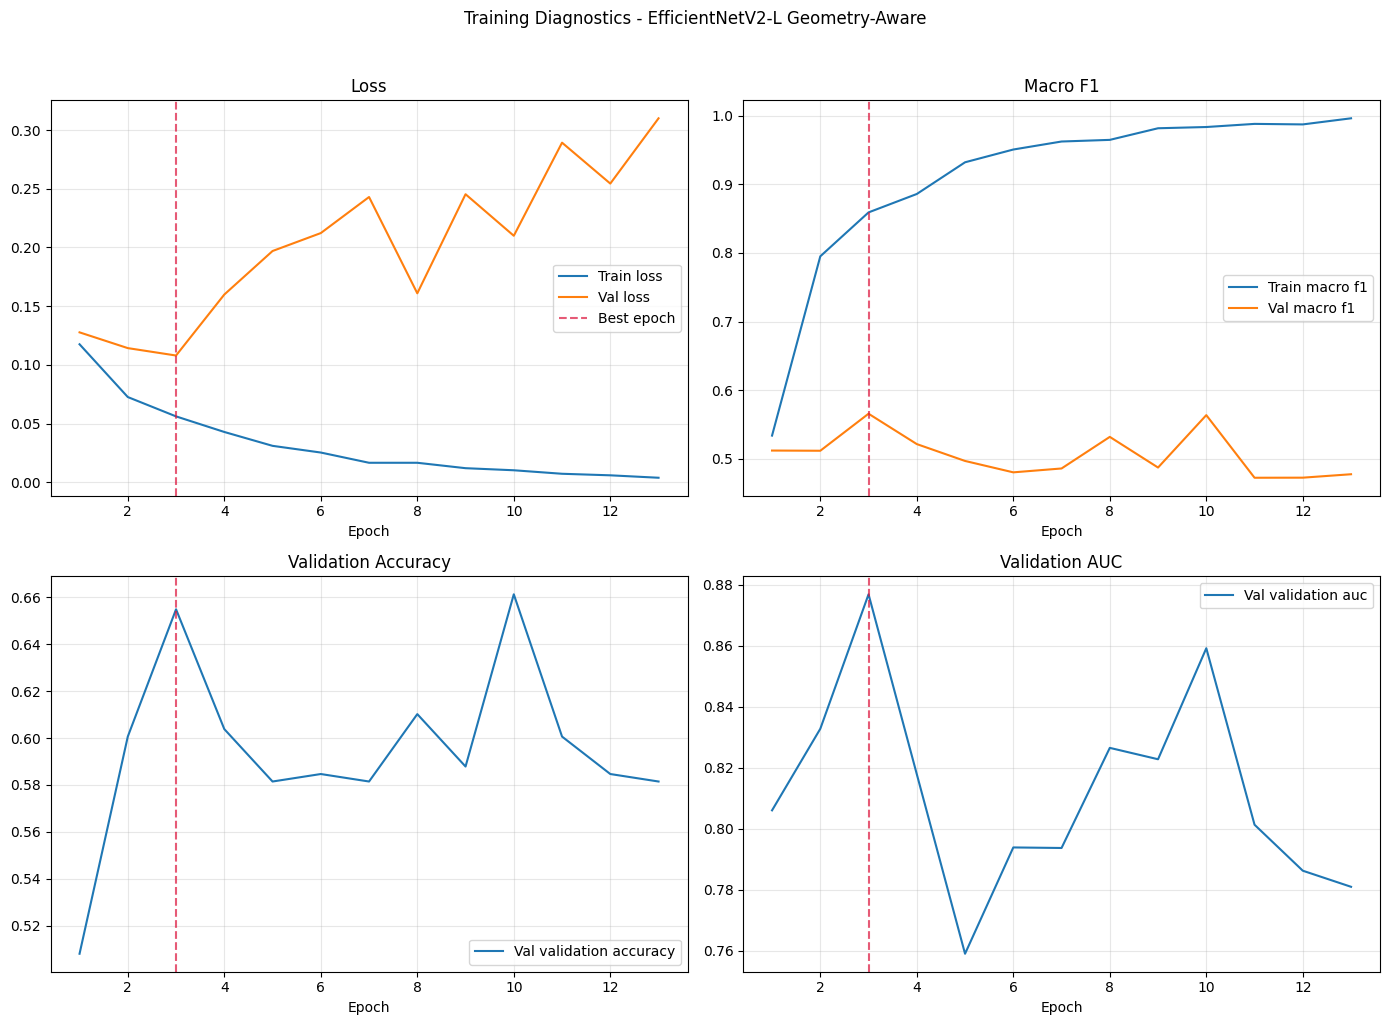

In [8]:
history_path = os.path.join(RESULTS_DIR, 'training_history_efficientnet_v2_l_geometry.csv')
checkpoint_path = os.path.join(MODELS_DIR, 'best_efficientnet_v2_l_geometry.pth')

history_df = globals().get('history_df')
if history_df is None or history_df.empty:
    if os.path.exists(history_path):
        history_df = pd.read_csv(history_path)
    else:
        raise FileNotFoundError(f'Missing training history at {history_path}. Use the already-trained notebook kernel or rerun a saved training job.')

history_df = history_df.sort_values('epoch').reset_index(drop=True)
history_df.to_csv(history_path, index=False)

best_epoch = globals().get('best_epoch')
if best_epoch is None:
    best_epoch = int(history_df.loc[history_df['val_macro_f1'].idxmax(), 'epoch'])
best_val_f1 = globals().get('best_val_f1')
if best_val_f1 is None:
    best_val_f1 = float(history_df['val_macro_f1'].max())

model = globals().get('model')
if model is None:
    model = build_efficientnet_v2_l(len(class_names), pretrained=False).to(device)
    if os.path.exists(checkpoint_path):
        model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.eval()

print('Best epoch:', best_epoch)
print('Best val macro F1:', best_val_f1)
display(history_df.tail())

plot_cols = [
    ('train_loss', 'val_loss', 'Loss'),
    ('train_macro_f1', 'val_macro_f1', 'Macro F1'),
    (None, 'val_accuracy', 'Validation Accuracy'),
    (None, 'val_auc', 'Validation AUC'),
]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()
for ax, (train_col, val_col, title) in zip(axes, plot_cols):
    if train_col is not None and train_col in history_df.columns:
        ax.plot(history_df['epoch'], history_df[train_col], label=f'Train {title.lower()}')
    if val_col in history_df.columns:
        ax.plot(history_df['epoch'], history_df[val_col], label=f'Val {title.lower()}')
    ax.axvline(best_epoch, color='crimson', linestyle='--', alpha=0.7, label='Best epoch' if ax is axes[0] else None)
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.grid(alpha=0.3)
    ax.legend()
fig.suptitle('Training Diagnostics - EfficientNetV2-L Geometry-Aware', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'training_diagnostics_efficientnet_v2_l_geometry.png'), dpi=200, bbox_inches='tight')
plt.show()

summary_rows = [{
    'best_epoch': best_epoch,
    'best_val_macro_f1': best_val_f1,
    'final_val_loss': float(history_df['val_loss'].iloc[-1]) if 'val_loss' in history_df.columns else np.nan,
    'final_val_accuracy': float(history_df['val_accuracy'].iloc[-1]) if 'val_accuracy' in history_df.columns else np.nan,
    'final_val_auc': float(history_df['val_auc'].iloc[-1]) if 'val_auc' in history_df.columns else np.nan,
}]
pd.DataFrame(summary_rows).to_csv(os.path.join(RESULTS_DIR, 'training_summary_efficientnet_v2_l_geometry.csv'), index=False)

Test metrics:
accuracy: 0.5039
balanced_accuracy: 0.4915
macro_f1: 0.4443
macro_precision: 0.5046
macro_recall: 0.4915
roc_auc_ovo_macro: 0.7967
pr_auc_macro: 0.5591
loss: 0.1416


,model,geometry_mode,use_clahe,test_accuracy,test_balanced_accuracy,test_macro_f1,test_macro_precision,test_macro_recall,test_roc_auc_ovo_macro,test_pr_auc_macro,test_loss
0,efficientnet_v2_l,pad_resize_if_rect,False,0.503937,0.49148,0.444325,0.504553,0.49148,0.796672,0.559102,0.141574


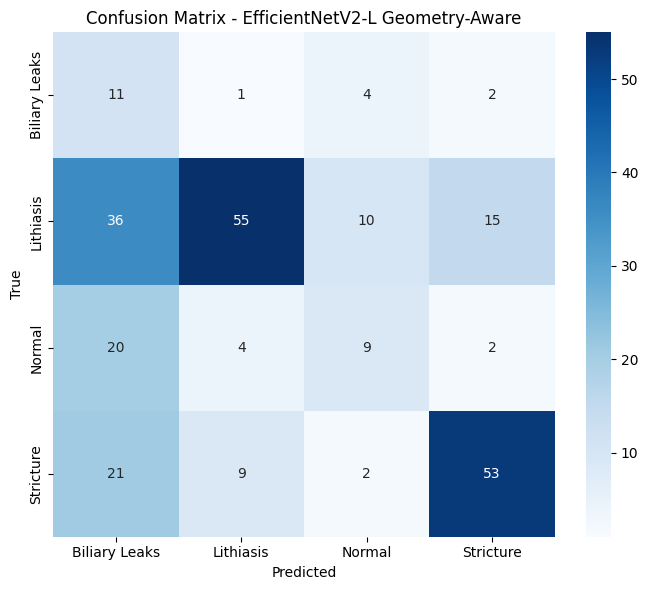

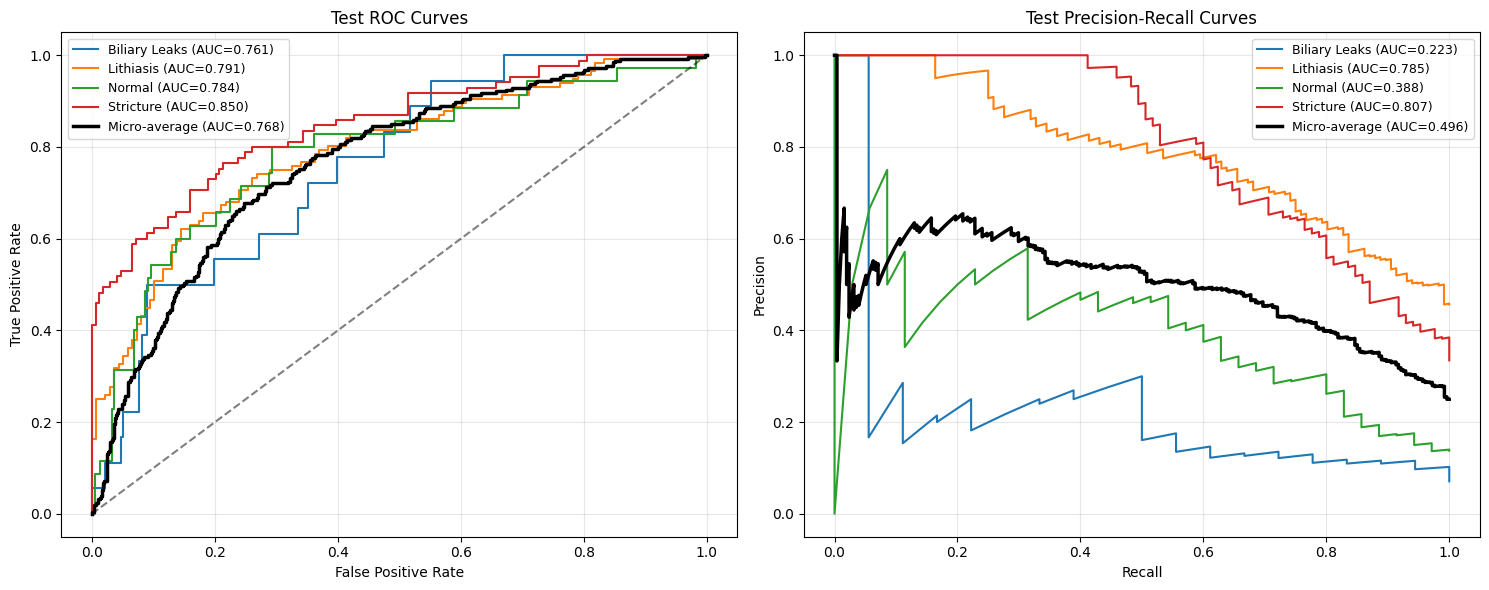

In [9]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc

checkpoint_path = os.path.join(MODELS_DIR, 'best_efficientnet_v2_l_geometry.pth')
model = globals().get('model')
if model is None:
    model = build_efficientnet_v2_l(len(class_names), pretrained=False).to(device)
    if os.path.exists(checkpoint_path):
        model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.eval()

criterion = FocalLoss(to_onehot_y=True)
test_metrics = globals().get('test_metrics')
y_true = globals().get('y_true')
y_pred = globals().get('y_pred')
y_prob = globals().get('y_prob')
if test_metrics is None or y_true is None or y_prob is None:
    test_metrics, y_true, y_pred, y_prob = evaluate(model, test_loader, criterion)

print('Test metrics:')
for k, v in test_metrics.items():
    print(f'{k}: {v:.4f}' if isinstance(v, (float, np.floating)) else f'{k}: {v}')

report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0)
cm = confusion_matrix(y_true, y_pred)

with open(os.path.join(RESULTS_DIR, 'classification_report_efficientnet_v2_l_geometry.json'), 'w') as f:
    json.dump(report, f, indent=2)

pd.DataFrame(report).transpose().to_csv(os.path.join(RESULTS_DIR, 'classification_report_efficientnet_v2_l_geometry.csv'))
pd.DataFrame(cm, index=class_names, columns=class_names).to_csv(os.path.join(RESULTS_DIR, 'confusion_matrix_efficientnet_v2_l_geometry.csv'))

summary = pd.DataFrame([{
    'model': 'efficientnet_v2_l',
    'geometry_mode': GEOMETRY_MODE,
    'use_clahe': USE_CLAHE,
    **{f'test_{k}': v for k, v in test_metrics.items()}
}])
summary.to_csv(os.path.join(RESULTS_DIR, 'test_summary_efficientnet_v2_l_geometry.csv'), index=False)
display(summary)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - EfficientNetV2-L Geometry-Aware')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'confusion_matrix_efficientnet_v2_l_geometry.png'), dpi=200, bbox_inches='tight')
plt.show()

y_true_bin = label_binarize(y_true, classes=list(range(len(class_names))))
fpr_micro, tpr_micro, _ = roc_curve(y_true_bin.ravel(), y_prob.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for idx, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_true_bin[:, idx], y_prob[:, idx])
    roc_auc_value = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, label=f'{class_name} (AUC={roc_auc_value:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].plot(fpr_micro, tpr_micro, label=f'Micro-average (AUC={roc_auc_micro:.3f})', linewidth=2.5, color='black')
axes[0].set_title('Test ROC Curves')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

precision_micro, recall_micro, _ = precision_recall_curve(y_true_bin.ravel(), y_prob.ravel())
pr_auc_micro = auc(recall_micro, precision_micro)
for idx, class_name in enumerate(class_names):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, idx], y_prob[:, idx])
    pr_auc_value = auc(recall, precision)
    axes[1].plot(recall, precision, label=f'{class_name} (AUC={pr_auc_value:.3f})')
axes[1].plot(recall_micro, precision_micro, label=f'Micro-average (AUC={pr_auc_micro:.3f})', linewidth=2.5, color='black')
axes[1].set_title('Test Precision-Recall Curves')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'roc_pr_curves_efficientnet_v2_l_geometry.png'), dpi=200, bbox_inches='tight')
plt.show()

In [12]:
# ============================================================
# CÉLULA FINAL — XAI: Grad-CAM + Occlusion Sensitivity
# Comparação entre previsões correctas e incorrectas
# ============================================================

import torch.nn.functional as F
import matplotlib.cm as mpl_cm
import matplotlib.patches as mpatches

# ── 1. Recolher previsões do conjunto de teste ───────────────
# (se já correste evaluate no teste, adapta para usar os arrays
#  que já tens; caso contrário re-avalia aqui)

criterion_xai = FocalLoss(to_onehot_y=True)
_, y_true_xai, y_pred_xai, y_prob_xai = evaluate(model, test_loader, criterion_xai)

# Construir dataframe com resultados por imagem
results_df = test_df.copy().reset_index(drop=True)
results_df['y_true'] = y_true_xai
results_df['y_pred'] = y_pred_xai
results_df['correct'] = results_df['y_true'] == results_df['y_pred']
results_df['confidence'] = [y_prob_xai[i, y_pred_xai[i]] for i in range(len(y_pred_xai))]

print("Correctas:", results_df['correct'].sum())
print("Incorrectas:", (~results_df['correct']).sum())


# ── 2. Grad-CAM ──────────────────────────────────────────────

class GradCAM:
    def __init__(self, model, target_layer):
        self.model       = model
        self.activations = None
        self.gradients   = None
        self._fwd = target_layer.register_forward_hook(
            lambda m, i, o: setattr(self, 'activations', o.detach())
        )
        self._bwd = target_layer.register_full_backward_hook(
            lambda m, gi, go: setattr(self, 'gradients', go[0].detach())
        )

    def generate(self, inp, class_idx=None):
        self.model.eval()
        out = self.model(inp)
        if class_idx is None:
            class_idx = out.argmax(1).item()
        self.model.zero_grad()
        out[0, class_idx].backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cam = cam.squeeze().cpu().numpy()
        if cam.max() > cam.min():
            cam = (cam - cam.min()) / (cam.max() - cam.min())
        return cam, class_idx

    def remove(self):
        self._fwd.remove()
        self._bwd.remove()


# ── 3. Occlusion Sensitivity ─────────────────────────────────

def occlusion_sensitivity(model, inp, class_idx, patch_size=40, stride=20):
    """
    Desliza um patch cinzento sobre a imagem e mede o impacto
    na probabilidade da classe alvo — zonas que causam maior
    queda são as mais importantes para a decisão.
    """
    model.eval()
    _, _, H, W = inp.shape
    baseline_prob = torch.softmax(model(inp), dim=1)[0, class_idx].item()
    heatmap = np.zeros((H, W))
    counts  = np.zeros((H, W))

    with torch.no_grad():
        for y in range(0, H - patch_size + 1, stride):
            for x in range(0, W - patch_size + 1, stride):
                occluded = inp.clone()
                occluded[:, :, y:y+patch_size, x:x+patch_size] = 0.0
                prob = torch.softmax(model(occluded), dim=1)[0, class_idx].item()
                drop = baseline_prob - prob   # quanto caiu a confiança
                heatmap[y:y+patch_size, x:x+patch_size] += drop
                counts[y:y+patch_size, x:x+patch_size]  += 1

    counts = np.maximum(counts, 1)
    heatmap = heatmap / counts
    heatmap = np.clip(heatmap, 0, None)
    if heatmap.max() > 0:
        heatmap = heatmap / heatmap.max()
    return heatmap


# ── 4. Selecção de exemplos: 1 correcto + 1 incorrecto por classe ──

def pick_examples(results_df, class_names, correct: bool, seed=42):
    rng = random.Random(seed)
    picked = []
    for cls_idx, cls_name in enumerate(class_names):
        subset = results_df[
            (results_df['y_true'] == cls_idx) &
            (results_df['correct'] == correct)
        ]
        if len(subset) == 0:
            print(f"  Sem exemplos {'correctos' if correct else 'incorrectos'} para {cls_name}")
            continue
        # Preferir exemplos com alta confiança (correctos) ou baixa (incorrectos)
        subset = subset.sort_values('confidence', ascending=not correct)
        row = subset.iloc[0]
        picked.append((cls_name, cls_idx, int(row.name),
                       row['y_pred'], row['confidence']))
    return picked


# ── 5. Função de visualização ─────────────────────────────────

denorm = T.Normalize(
    mean=[-m/s for m, s in zip(IMAGENET_MEAN, IMAGENET_STD)],
    std=[1/s for s in IMAGENET_STD]
)

def render_xai_grid(examples, title, save_name):
    """
    Para cada exemplo: Original | Occlusion overlay | Grad-CAM heatmap | Grad-CAM overlay
    """
    n = len(examples)
    fig, axes = plt.subplots(n, 4, figsize=(16, 4.2 * n))
    if n == 1:
        axes = axes[np.newaxis, :]

    col_titles = ['Original', 'Occlusion overlay', 'Grad-CAM heatmap', 'Grad-CAM overlay']
    for col, ct in enumerate(col_titles):
        axes[0, col].set_title(ct, fontsize=11, fontweight='bold', pad=8)

    # Instanciar Grad-CAM uma única vez — última conv do EfficientNetV2-L
    target_layer = model.features[-1][0]
    gradcam = GradCAM(model, target_layer)

    for row, (cls_name, true_idx, df_idx, pred_idx, conf) in enumerate(examples):
        img_tensor, _ = test_ds[df_idx]
        inp = img_tensor.unsqueeze(0).to(device)

        # Grad-CAM (backprop para a classe PREDITA)
        cam, _ = gradcam.generate(inp, class_idx=pred_idx)
        cam_resized = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))

        # Occlusion (classe PREDITA — o que o modelo estava a olhar)
        occ_map = occlusion_sensitivity(model, inp, pred_idx,
                                patch_size=80, stride=40)

        # Imagem desnormalizada
        img_vis = denorm(img_tensor).permute(1, 2, 0).clamp(0, 1).numpy()

        # Overlays
        gc_overlay  = np.clip(0.55 * img_vis + 0.45 * mpl_cm.jet(cam_resized)[:,:,:3], 0, 1)
        occ_overlay = np.clip(0.55 * img_vis + 0.45 * mpl_cm.hot(occ_map)[:,:,:3],     0, 1)

        pred_name  = class_names[pred_idx]
        correct    = (true_idx == pred_idx)
        border_col = '#2ecc71' if correct else '#e74c3c'

        for col, img_data in enumerate([img_vis, occ_overlay,
                                        mpl_cm.jet(cam_resized)[:,:,:3], gc_overlay]):
            ax = axes[row, col]
            ax.imshow(img_data)
            ax.axis('off')
            for spine in ax.spines.values():
                spine.set_edgecolor(border_col)
                spine.set_linewidth(3)
                spine.set_visible(True)

        # Título por baixo de cada imagem na coluna 0 — classe real
        axes[row, 0].set_title(f"Real: {cls_name}", fontsize=9, loc='left', pad=4)

        # Título na coluna 3 — classe predita + confiança + símbolo
        symbol = '✓' if correct else '✗'
        axes[row, 3].set_title(
            f"Pred: {pred_name} {symbol} ({conf:.2f})",
            fontsize=9, loc='right', pad=4,
            color='#2ecc71' if correct else '#e74c3c'
        )

    fig.suptitle(title, fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    save_path = os.path.join(RESULTS_DIR, save_name)
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Guardado em {save_path}")

    gradcam.remove()


# ── 6. Gerar as duas grelhas ──────────────────────────────────

print("A gerar XAI para previsões CORRECTAS...")
correct_examples   = pick_examples(results_df, class_names, correct=True)
render_xai_grid(
    correct_examples,
    title="XAI: Grad-CAM + Occlusion — EfficientNetV2-L (exemplos correctos, 1 por classe)",
    save_name="xai_correct_examples.png"
)

print("\nA gerar XAI para previsões INCORRECTAS...")
wrong_examples = pick_examples(results_df, class_names, correct=False)
render_xai_grid(
    wrong_examples,
    title="XAI: Grad-CAM + Occlusion — EfficientNetV2-L (exemplos incorrectos, 1 por classe)",
    save_name="xai_wrong_examples.png"
)

print("\nDone. Imagens guardadas em", RESULTS_DIR)

KeyboardInterrupt: 

## Notes
- This notebook is intentionally aligned with the stronger EfficientNet setup.
- If you want direct comparability against `filter_benchmark_clahe`, keep the same patient split seed and report macro F1/AUC side by side.
- To run an ablation, switch `GEOMETRY_MODE` to `direct_resize` and rerun.